# Implement the QMI monitored dynamics with hardward noise from IBM Quantum backend.
In this notebook we choose **hardware-efficient ansatz** for both idea, noisy simulation and on-device experiement.

We choose the nearset-neighbor connectitivity for the two-qubits gate and use CZ as the entangling gate in our ansatz.

We perform both QMI and CMI simulation.

In [1]:
import numpy as np
import qutip as qt
from itertools import combinations
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
import time

import qiskit
from qiskit.circuit.library import HamiltonianGate, UnitaryGate
from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.quantum_info import partial_trace, entropy, mutual_information, purity, Statevector
from qiskit.visualization import plot_state_city
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.primitives import BackendSamplerV2, BitArray
from qiskit_ibm_runtime import QiskitRuntimeService, Batch, SamplerV2
from qiskit_ibm_runtime.ibm_backend import IBMBackend
from qiskit_aer.library.save_instructions.save_density_matrix import SaveDensityMatrix


from qutip.random_objects import rand_unitary


from MCM_utils import scrambling_circuit_ECR_d, scrambling_circuit_CZ_d, IsingHamiltonian, \
adding_dynamical_decoupling, postprocessing_CMI_experiment, n_qubit_cmi, n_qubit_qmi, bitarray_to_CMI

C:\Users\ASW114514\AppData\Local\Temp\ipykernel_46480\4052000420.py:18: DeprecationWarning: Using qiskit-ibm-runtime with Python 3.9 is deprecated as of the 0.41.0 release. Support for running qiskit-ibm-runtime with Python 3.9 will be removed in a future release.
  from qiskit_ibm_runtime import QiskitRuntimeService, Batch, SamplerV2


# QMI

## QMI helper func

### Circuit structure

In [2]:
# Base circuit for all experiment
def base_QRC_circuit(t, data_size, ancilla_size, L=4, reset_qubit=True, all_to_all=False,
                     seed=114514) -> QuantumCircuit:
    """
    The base circuit structure for the QRC memory circuit.
    The initial state for data (A) and idle (B) qubits is the maximally entangled state: 
        |\psi\rangle = \frac{1}{\sqrt{8}} \sum_{i=0}^{7} |i\rangle_A \otimes |i\rangle_B
    
    Args:
        t (int): The number of steps.
        data_size (int): The number of the data qubits.
        ancilla_size (int): The number of the ancilla/bath qubits.
        L (int): The number of layers for each scrambling circuit. 
        reset_qubit (bool): Whether to reset the ancilla qubit after the mid-circuit measurement.
        all_to_all (bool): Whether to use all-to-all connectivity in the fast scrambling circuit.
        seed (int): The seed for the random number generator used to construct the fast scrambling circuit.
    """

    # Create the qubit and classic registers and quantum circuit
    n_tot = 2*data_size + ancilla_size
    q_reg_idle = QuantumRegister(data_size, 'idle')
    q_reg_data = QuantumRegister(data_size, 'data')
    q_reg_ancilla = QuantumRegister(ancilla_size, 'ancilla')
    ancilla_reg = ClassicalRegister(max(ancilla_size, ancilla_size*t), 'ancilla_meas')
    system_reg = ClassicalRegister(2*data_size, 'system_meas')
    circuit = QuantumCircuit(q_reg_idle, q_reg_data, q_reg_ancilla, ancilla_reg, system_reg)

    # Initialize the maximally entangled state on idle and data qubits
    for i in range(data_size):
        circuit.h(q_reg_idle[i])
        circuit.cx(q_reg_idle[i], q_reg_data[i])
    circuit.barrier()


    # Apply the fast scrambling circuit to mimic Haar random unitary at each step
    for i in range(t):
        # Generate the fast scrambling circuit
        fast_scrambling = scrambling_circuit_CZ_d(data_size+ancilla_size, L, seed + 114*i, all_to_all=all_to_all)
        circuit.compose(fast_scrambling, qubits=q_reg_data[:] + q_reg_ancilla[:], inplace=True)
        circuit.measure(q_reg_ancilla, ancilla_reg[i*ancilla_size:(i+1)*ancilla_size])
        if reset_qubit:
            circuit.reset(q_reg_ancilla)
        circuit.barrier()

    return circuit

### Simulation function

In [3]:
def QRC_ideal_simulation(t, L, simulator, data_size, ancilla_size, shots=1024, reset_qubit=True,
                          measurement_conditioned=True, all_to_all=False, seed=114514):
    """
    Run the simulation for the QRC memory circuit and calculate the quantum mutual information (QMI) of the resulting state.
    In this case we use Von Neumann entropy for the QMI.

    The initial state for data and idle qubits is the maximally entangled state: |\psi\rangle = \frac{1}{\sqrt{8}} \sum_{i=0}^{7} |i\rangle_A \otimes |i\rangle_B

    Args:
        t (int): The number of steps.
        L (int): The depth.
        simulator (qiskit_aer.AerSimulator): The AerSimulator to run the simulation.
        data_size (int): The number of the data qubits.
        ancilla_size (int): The number of the ancilla/bath qubits.
        shots (int): The number of shots for the simulation.
        reset_qubit (bool): Whether to reset the ancilla qubit after the mid-circuit measurement.
        measurement_conditioned (bool): Whether to save the conditional density matrix conditioned on the previous measurement.
        all_to_all (bool): Whether to use all-to-all connectivity in the fast scrambling circuit. Default is False, which corresponds to nearest-neighbor connectivity.
        seed (int): The random seed for the Hamiltonian or the unitaries or fast scrambling parameter.
    
    Returns:
        Tuple(float, float): The quantum mutual information (QMI) and purity of the resulting state.
    """

    # Initialize the pass manager (circuit transpiler)
    pm = generate_preset_pass_manager(backend=simulator, optimization_level=3)

    # Prepare the circuit
    QRC_circ = base_QRC_circuit(t, data_size, ancilla_size, L=L, reset_qubit=reset_qubit,
                                    all_to_all=all_to_all, seed=seed)
    
    # Running simulation
    # If measurement_conditioned is True, calculate the weighted average QMI of each conditional density matrix
    if measurement_conditioned and t!=0:
        QRC_circ.save_density_matrix(conditional=True)
        # Compile the circuit
        tcirc = pm.run(QRC_circ)
        # running the simulation and obtain the count and density matrix
        result_data = simulator.run(tcirc, shots=shots).result().data()
        dm_dict = result_data['density_matrix']
        
        count_dict = result_data['counts']
        total_QMI = 0
        purity_val = 0
        for bitstring, dm in dm_dict.items():
            count = count_dict[bitstring]
            conditioned_QMI = n_qubit_qmi(dm, list(range(data_size)), list(range(data_size, 2*data_size)), list(range(2*data_size, 2*data_size + ancilla_size)))
            total_QMI += conditioned_QMI * count
            purity_val += purity(dm) * count
        return total_QMI / shots
    
    # Otherwise, first extract the unconditioned density matrix, then calculate the unconditioned QMI
    else:
        QRC_circ.save_density_matrix(conditional=False)
        # Compile the circuit
        tcirc = pm.run(QRC_circ) 
        result_data = simulator.run(tcirc, shots=shots).result().data()
        dm = result_data['density_matrix']
        unconditioned_QMI = n_qubit_qmi(dm, list(range(data_size)), list(range(data_size, 2*data_size)), list(range(2*data_size, 2*data_size + ancilla_size)))
        return unconditioned_QMI



In [4]:
def QRC_noisy_simulation(t, L, backend, data_size, ancilla_size, seed=114514, shots=1024, reset_qubit=True, 
                         measurement_conditioned=True, with_readout=True, with_idle=True, all_to_all=False):
    '''
    QMI decaying simulation for fast scrambling circuit with optional readout error and idle noise.
    If with_readout is True, include readout error in the simulation.
    If with_idle is True, include idling noise in the simulation.

    Args:
        t (int): The timestep at which we are interested.
        L (int): The number of qubits in the system.
        backend (Backend): The quantum backend to run the simulation on.
        data_size (int): The number of data qubits.
        ancilla_size (int): The number of ancilla qubits.
        shots (int): The number of shots for the simulation. Defaults to 1024.
        reset_qubit (bool): Whether to reset qubits during the simulation. Defaults to True.
        measurement_conditioned (bool): Whether the simulation is measurement conditioned. Defaults to True.
        with_readout (bool): Whether to include readout error in the simulation. Defaults to True.
        with_idle (bool): Whether to include idling noise in the simulation. Defaults to True.
    Returns:
        float: The quantum mutual information at timestep t.
    '''

    noise_model = NoiseModel.from_backend(backend, gate_error=True, thermal_relaxation=True, readout_error=with_readout)
    simulator = AerSimulator.from_backend(backend, noise_model=noise_model)
    try:
        simulator.target.add_instruction(SaveDensityMatrix, name="save_density_matrix")
    except AttributeError:
        pass
    
    # Prepare pass manager (circuit transpiler)
    if with_idle: # if including idling_error, pre-compile the circuit
        pm = generate_preset_pass_manager(backend=simulator, optimization_level=3, scheduling_method='alap')
    else:
        pm = generate_preset_pass_manager(backend=simulator, optimization_level=3)

    # Prepare circuit
    QRC_circ = base_QRC_circuit(t, data_size, ancilla_size, L=L, reset_qubit=reset_qubit,
                                all_to_all=all_to_all, seed=seed)

    # Running simulation
    if measurement_conditioned and t!=0:
        # Compile the circuit
        tcirc = pm.run(QRC_circ)
        layout = tcirc.layout.final_index_layout()
        tcirc.save_density_matrix(qubits=layout, pershot=True)
        

        # running the simulation and obtain the density matrix
        result_data = simulator.run(tcirc, shots=shots).result().data()

        dm_list = result_data['density_matrix']
        qmi_list = np.array([n_qubit_qmi(dm, list(range(data_size)), list(range(data_size, 2*data_size)), list(range(2*data_size, 2*data_size + ancilla_size))) for dm in dm_list])
        return qmi_list.mean()
    else:
        # Compile the circuit
        tcirc = pm.run(QRC_circ)
        layout = tcirc.layout.final_index_layout()
        tcirc.save_density_matrix(qubits=layout)

        # running the simulation and obtain the density matrix
        result_data = simulator.run(tcirc, shots=shots).result().data()

        dm = result_data['density_matrix']
        return n_qubit_qmi(dm, list(range(data_size)), list(range(data_size, 2*data_size)), list(range(2*data_size, 2*data_size + ancilla_size)))   

## All QMI simulation

in the noisy simulation, we use the base noise model with [qiskit.aer.NoiseModel](https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.noise.NoiseModel.html), with a combination of
- readout error
- 1 and 2 qubit gate error (depolarizing_error followed by a thermal relaxation error)
- idling error

we try a few combination of the three error sources above to check which error contribute the most in QMI decay.

###  Ideal simulation

In [5]:
ideal_simulator = AerSimulator()

n=3
na=1
L=4
T = 1
repeat = 1
all_to_all = False
circ_label = 'czfs_all_to_all' if all_to_all else 'czfs'
# initialize different random seeds for each run
np.random.seed(19810)
seed_list = np.random.randint(0, 1e7, (repeat, T))

ideal_CZfs_cond_QMI = np.zeros((repeat, T))
ideal_CZfs_uncond_QMI = np.zeros((repeat, T))
for i in tqdm(range(repeat)):
    for t in range(T):
        ideal_CZfs_cond_result = QRC_ideal_simulation(t, L, ideal_simulator, n, na, shots=100000, reset_qubit=True,
                                                    measurement_conditioned=True, all_to_all=all_to_all, seed=seed_list[i, t])
        
        ideal_CZfs_uncond_result = QRC_ideal_simulation(t, L, ideal_simulator, n, na, shots=100000, reset_qubit=True,
                                                    measurement_conditioned=False, all_to_all=all_to_all, seed=seed_list[i, t])
        ideal_CZfs_cond_QMI[i, t] = ideal_CZfs_cond_result
        ideal_CZfs_uncond_QMI[i, t] = ideal_CZfs_uncond_result
    # print(ideal_ECRfs_conditioned_QMI)
try:
    os.makedirs(f"data/ideal/unconditioned/reset/{circ_label}/dm", exist_ok=False)
except FileExistsError:
    pass
try:
    os.makedirs(f"data/ideal/conditioned/reset/{circ_label}/dm", exist_ok=False)
except FileExistsError:
    pass
np.save(f"data/ideal/conditioned/reset/{circ_label}/dm/qmi_n{n}na{na}T{T}L{L}.npy", ideal_CZfs_cond_QMI)
np.save(f"data/ideal/unconditioned/reset/{circ_label}/dm/qmi_n{n}na{na}T{T}L{L}.npy", ideal_CZfs_uncond_QMI)

# plt.errorbar(range(T), ideal_CZfs_cond_QMI.mean(axis=0), yerr=ideal_CZfs_cond_QMI.std(axis=0), fmt='o', capsize=5, 
#              label="Conditioned QMI")
# plt.errorbar(range(T), ideal_CZfs_uncond_QMI.mean(axis=0), yerr=ideal_CZfs_uncond_QMI.std(axis=0), fmt='s', capsize=5,
#              label="Unconditioned QMI")
# plt.xlabel("Time steps")
# plt.ylabel("QMI")
# plt.title("Conditioned and Unconditioned QMI vs Time steps")
# plt.legend()
# plt.grid(True)
# plt.show()
# np.save(f"data/ideal/conditioned/reset/{circ_label}/dm/qmi_n{n}na{na}T{T}L{L}.npy", ideal_CZfs_cond_QMI)
# np.save(f"data/ideal/unconditioned/reset/{circ_label}/dm/qmi_n{n}na{na}T{T}L{L}.npy", ideal_CZfs_uncond_QMI)

100%|██████████| 1/1 [00:00<00:00,  1.00it/s]


### Complete noisy simulation for QMI

In [ ]:
service = QiskitRuntimeService()
aachen = service.backends('ibm_aachen')[0]

n=3
na=1
L=4
T = 7
repeat = 10
all_to_all = False
circ_label = 'czfs_all_to_all' if all_to_all else 'czfs'
np.random.seed(19810)
seed_list = np.random.randint(0, 1e7, (repeat, T))

comp_noisy_CZfs_cond_QMI = np.zeros((repeat, T))
comp_noisy_CZfs_uncond_QMI = np.zeros((repeat, T))
for i in tqdm(range(repeat)):
    for t in range(T):
        comp_noisy_CZfs_cond_result = QRC_noisy_simulation(t, L, aachen, n, na, seed=seed_list[i, t], shots=10000,
                                                           reset_qubit=True, measurement_conditioned=True,
                                                           with_readout=True, with_idle=True, all_to_all=all_to_all)
        comp_noisy_CZfs_uncond_result = QRC_noisy_simulation(t, L, aachen, n, na, seed=seed_list[i, t], shots=10000,
                                                             reset_qubit=True, measurement_conditioned=False,
                                                             with_readout=True, with_idle=True, all_to_all=all_to_all)
        comp_noisy_CZfs_cond_QMI[i, t] = comp_noisy_CZfs_cond_result
        comp_noisy_CZfs_uncond_QMI[i, t] = comp_noisy_CZfs_uncond_result

try:
    os.makedirs(f"data/comp_noisy/conditioned/reset/{circ_label}/dm", exist_ok=False)
except FileExistsError:
    pass
try:
    os.makedirs(f"data/comp_noisy/unconditioned/reset/{circ_label}/dm", exist_ok=False)
except FileExistsError:
    pass
np.save(f'data/comp_noisy/conditioned/reset/{circ_label}/dm/qmi_n{n}na{na}T{T}L{L}.npy', comp_noisy_CZfs_cond_QMI)
np.save(f'data/comp_noisy/unconditioned/reset/{circ_label}/dm/qmi_n{n}na{na}T{T}L{L}.npy', comp_noisy_CZfs_uncond_QMI)

100%|██████████| 1/1 [00:12<00:00, 12.65s/it]


### Noisy w/ idling error w/o readout error simulation

In [ ]:
aachen = service.backends('ibm_aachen')[0]

n=3
na=1
L=6
T = 7
repeat = 10
seed_list = np.random.randint(0, 1e7, (repeat, T))

idle_no_readout_CZfs_cond_QMI = np.zeros((repeat, T))
idle_no_readout_CZfs_uncond_QMI = np.zeros((repeat, T))
for i in tqdm(range(repeat)):
    for t in range(T):
        idle_no_readout_CZfs_cond_result = QRC_noisy_simulation(t, L, aachen, n, na, seed=seed_list[i, t], shots=1000,
                                                                reset_qubit=True, measurement_conditioned=True,
                                                                with_readout=False, with_idle=True)
        idle_no_readout_CZfs_uncond_result = QRC_noisy_simulation(t, L, aachen, n, na, seed=seed_list[i, t], shots=1000,
                                                                  reset_qubit=True, measurement_conditioned=False,
                                                                  with_readout=False, with_idle=True)
        idle_no_readout_CZfs_cond_QMI[i, t] = idle_no_readout_CZfs_cond_result
        idle_no_readout_CZfs_uncond_QMI[i, t] = idle_no_readout_CZfs_uncond_result

try:
    os.makedirs("data/noisy_idle_no_readout/conditioned/reset/czfs/dm", exist_ok=False)
except FileExistsError:
    pass
try:
    os.makedirs("data/noisy_idle_no_readout/unconditioned/reset/czfs/dm", exist_ok=False)
except FileExistsError:
    pass
np.save(f'data/noisy_idle_no_readout/conditioned/reset/czfs/dm/qmi_n{n}na{na}T{T}L{L}.npy', idle_no_readout_CZfs_cond_QMI)
np.save(f'data/noisy_idle_no_readout/unconditioned/reset/czfs/dm/qmi_n{n}na{na}T{T}L{L}.npy', idle_no_readout_CZfs_uncond_QMI)

100%|██████████| 1/1 [00:13<00:00, 13.13s/it]


### Noisy w/o idling error w/ readout error simulation


In [ ]:
aachen = service.backends('ibm_aachen')[0]

n=3
na=1
L=6
T = 7
repeat = 10
seed_list = np.random.randint(0, 1e7, (repeat, T))

no_idle_readout_CZfs_cond_QMI = np.zeros((repeat, T))
no_idle_readout_CZfs_uncond_QMI = np.zeros((repeat, T))
for i in tqdm(range(repeat)):
    for t in range(T):
        no_idle_readout_CZfs_cond_result = QRC_noisy_simulation(t, L, aachen, n, na, seed=seed_list[i, t], shots=1000,
                                                                reset_qubit=True, measurement_conditioned=True,
                                                                with_readout=True, with_idle=False)
        no_idle_readout_CZfs_uncond_result = QRC_noisy_simulation(t, L, aachen, n, na, seed=seed_list[i, t], shots=1000,
                                                                  reset_qubit=True, measurement_conditioned=False,
                                                                  with_readout=True, with_idle=False)
        no_idle_readout_CZfs_cond_QMI[i, t] = no_idle_readout_CZfs_cond_result
        no_idle_readout_CZfs_uncond_QMI[i, t] = no_idle_readout_CZfs_uncond_result

try:
    os.makedirs("data/noisy_no_idle_readout/conditioned/reset/czfs/dm", exist_ok=False)
except FileExistsError:
    pass
try:
    os.makedirs("data/noisy_no_idle_readout/unconditioned/reset/czfs/dm", exist_ok=False)
except FileExistsError:
    pass
np.save(f'data/noisy_no_idle_readout/conditioned/reset/czfs/dm/qmi_n{n}na{na}T{T}L{L}.npy', no_idle_readout_CZfs_cond_QMI)
np.save(f'data/noisy_no_idle_readout/unconditioned/reset/czfs/dm/qmi_n{n}na{na}T{T}L{L}.npy', no_idle_readout_CZfs_uncond_QMI)

100%|██████████| 1/1 [00:10<00:00, 10.62s/it]


### Noisy w/o idling error w/o readout error simulation

In [12]:
aachen = service.backends('ibm_aachen')[0]

n=3
na=1
L=6
T = 1
repeat = 1
seed_list = np.random.randint(0, 1e7, (repeat, T))

no_idle_no_readout_CZfs_cond_QMI = np.zeros((repeat, T))
no_idle_no_readout_CZfs_uncond_QMI = np.zeros((repeat, T))
for i in tqdm(range(repeat)):
    for t in range(T):
        no_idle_no_readout_CZfs_cond_result = QRC_noisy_simulation(t, L, aachen, n, na, seed=seed_list[i, t], shots=1000,
                                                                   reset_qubit=True, measurement_conditioned=True,
                                                                   with_readout=False, with_idle=False)
        # assert False
        no_idle_no_readout_CZfs_uncond_result = QRC_noisy_simulation(t, L, aachen, n, na, seed=seed_list[i, t], shots=1000,
                                                                     reset_qubit=True, measurement_conditioned=False,
                                                                     with_readout=False, with_idle=False)
        no_idle_no_readout_CZfs_cond_QMI[i, t] = no_idle_no_readout_CZfs_cond_result
        no_idle_no_readout_CZfs_uncond_QMI[i, t] = no_idle_no_readout_CZfs_uncond_result

try:
    os.makedirs("data/noisy_no_idle_no_readout/conditioned/reset/czfs/dm", exist_ok=False)
except FileExistsError:
    pass
try:
    os.makedirs("data/noisy_no_idle_no_readout/unconditioned/reset/czfs/dm", exist_ok=False)
except FileExistsError:
    pass
np.save(f'data/noisy_no_idle_no_readout/conditioned/reset/czfs/dm/qmi_n{n}na{na}T{T}L{L}.npy', no_idle_no_readout_CZfs_cond_QMI)
np.save(f'data/noisy_no_idle_no_readout/unconditioned/reset/czfs/dm/qmi_n{n}na{na}T{T}L{L}.npy', no_idle_no_readout_CZfs_uncond_QMI)

100%|██████████| 1/1 [00:09<00:00,  9.69s/it]


# CMI
In simualtion, there are two way to calculate the CMI:
- extract the density matrix after evolution
- using measurement outcome to calculate

## CMI helper func

In [20]:
# Directly using density matrix to calculate the CMI
def ideal_CMI_simulation_dm(t, simulator, data_size, ancilla_size, L=6, shots=1024, reset_qubit=True,
                          measurement_conditioned=True, all_to_all=False, seed=114514) -> float:
    """
    Run the simulation for the QRC memory circuit and calculate the classical mutual information (CMI) of the resulting state
    in the Z-basis.
    This function only applies to fast scrambling experiment now.

    Args:
        t (int): The number of steps.
        simulator (qiskit_aer.AerSimulator): The AerSimulator to run the simulation.
        data_size (int): The number of the data qubits.
        ancilla_size (int): The number of the ancilla/bath qubits.
        shots (int): The number of shots for the simulation.
        reset_qubit (bool): Whether to reset the ancilla qubit after the mid-circuit measurement.
        measurement_conditioned (bool): Whether to save the density matrix conditioned on the measurement.
        seed (int): The random seed for fast scrambling parameter generation.
    Returns:
        float: The classical mutual information (CMI) between the data and idle qubits.
    """
    
    # Initialize transpiler
    pm = generate_preset_pass_manager(backend=simulator, optimization_level=3)

    # Prepare the circuit
    QRC_circ = base_QRC_circuit(t, data_size, ancilla_size, L=L, reset_qubit=reset_qubit, 
                                all_to_all=all_to_all, seed=seed)
    
    if measurement_conditioned and t!=0:
        QRC_circ.save_density_matrix(conditional=measurement_conditioned)
        tcirc = pm.run(QRC_circ)
        result = simulator.run(tcirc, shots=shots).result()
        result_data = result.data()
        dm_dict = result_data['density_matrix']
        
        count_dict = result_data['counts']
        total_cmi = 0
        for bitstring, dm in dm_dict.items():
            count = count_dict[bitstring]
            conditioned_cmi = n_qubit_cmi(dm, list(range(data_size)), list(range(data_size, 2*data_size)), list(range(2*data_size, 2*data_size + ancilla_size)))
            total_cmi += conditioned_cmi * count
        return total_cmi.real / shots#, dm_dict, result

    else:   
        QRC_circ.save_density_matrix()
        tcirc = pm.run(QRC_circ)
        dm = simulator.run(tcirc, shots=shots).result().data()['density_matrix']
        unconditioned_cmi = n_qubit_cmi(dm, list(range(data_size)), list(range(data_size, 2*data_size)), list(range(2*data_size, 2*data_size + ancilla_size)))
        return unconditioned_cmi.real
    

# noisy version
def noisy_CMI_simulation_dm(t, backend, data_size, ancilla_size, L=6, shots=1024, reset_qubit=True, with_idle=False, 
                            with_readout=True, measurement_conditioned=True, all_to_all=False, gpu=False, seed=114514) -> float:
    """
    Run the simulation for the QRC memory circuit and calculate the classical mutual information (CMI) of the resulting state
    in the Z-basis.
    This function only applies to fast scrambling experiment now.

    Args:
        t (int): The number of steps.
        backend (qiskit_aer.AerSimulator): The AerSimulator to run the simulation.
        data_size (int): The number of the data qubits.
        ancilla_size (int): The number of the ancilla/bath qubits.
        shots (int): The number of shots for the simulation.
        reset_qubit (bool): Whether to reset the ancilla qubit after the mid-circuit measurement.
        measurement_conditioned (bool): Whether to save the density matrix conditioned on the measurement.
        seed (int): The random seed for fast scrambling parameter generation.
    Returns:
        float: The classical mutual information (CMI) between the data and idle qubits.
    """

    # simulator = AerSimulator(noise_model=NoiseModel.from_backend(backend, readout_error=with_readout))
    noise_model = NoiseModel.from_backend(backend, readout_error=with_readout, thermal_relaxation=True, gate_error=True)
    if gpu:
        simulator = AerSimulator.from_backend(backend, noise_model=noise_model, method='density_matrix', device='GPU', batched_shots_gpu=True)
    else:
        simulator = AerSimulator.from_backend(backend, noise_model=noise_model, method='density_matrix')
    try:
        simulator.target.add_instruction(SaveDensityMatrix, name="save_density_matrix")
    except AttributeError:
        pass
    # Initialize transpiler
    
    if with_idle: # if including idling_error, pre-compile the circuit
        pm = generate_preset_pass_manager(backend=simulator, optimization_level=3, scheduling_method='alap')
    else:
        pm = generate_preset_pass_manager(backend=simulator, optimization_level=3)

    # Prepare the circuit
    QRC_circ = base_QRC_circuit(t, data_size, ancilla_size, L=L, reset_qubit=reset_qubit, 
                                all_to_all=all_to_all, seed=seed)
    
    if measurement_conditioned and t!=0:
        tcirc = pm.run(QRC_circ)
        layout = tcirc.layout.final_index_layout()
        tcirc.save_density_matrix(qubits=layout, pershot=True)
        
        result_data = simulator.run(tcirc, shots=shots).result().data()
        
        dm_list = result_data['density_matrix']
        qmi_list = np.array([n_qubit_cmi(dm, list(range(data_size)), list(range(data_size, 2*data_size)), list(range(2*data_size, 2*data_size + ancilla_size))) for dm in dm_list])
        return qmi_list.mean().real

    else:   
        tcirc = pm.run(QRC_circ)
        layout = tcirc.layout.final_index_layout()
        tcirc.save_density_matrix(qubits=layout)
        result_data = simulator.run(tcirc, shots=shots).result().data()

        dm = result_data['density_matrix']
        return n_qubit_cmi(dm, list(range(data_size)), list(range(data_size, 2*data_size)), list(range(2*data_size, 2*data_size + ancilla_size))).real


In [27]:
# Using the measurement result to calculate the CMI
def CMI_experiment_meas(t, backend, data_size, ancilla_size, L=6, shots=1024, reset_qubit=True, with_idle=False, all_to_all=False,
                        seed=114514) -> float:
    """
    Run the simulation for the QRC memory circuit and calculate the classical mutual information (CMI) of the resulting state
    in the Z-basis.
    This function only applies to fast scrambling experiment now.

    Args:
        t (int): The number of steps.
        backend (qiskit_aer.AerSimulator | qiskit_ibm_runtime.ibm_backend.IBMBackend): The backend to run the experiment.
        data_size (int): The number of the data qubits.
        ancilla_size (int): The number of the ancilla/bath qubits.
        L (int): The number of qubits in the system.
        shots (int): The number of shots for the simulation.
        reset_qubit (bool): Whether to reset the ancilla qubit after the mid-circuit measurement.
        with_idle (bool): Whether to include idling noise in the simulation.
        all_to_all (bool): Whether to use all-to-all connectivity in the fast scrambling circuit
        seed (int): The random seed for fast scrambling parameter generation.
    Returns:
        float: The classical mutual information (CMI) between the data and idle qubits.
    """
    
    # Initialize transpiler
    if with_idle:
        pm = generate_preset_pass_manager(backend=backend, optimization_level=3, scheduling_method='alap')
    else:
        pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

    # Prepare the circuit
    QRC_circ = base_QRC_circuit(t, data_size, ancilla_size, L=L, reset_qubit=reset_qubit,
                                all_to_all=all_to_all, seed=seed)
    QRC_circ.measure(list(range(0, 2*data_size)), QRC_circ.cregs[1])  # Measure all data and idle qubits
    
    # Transpile the circuit
    tcirc = pm.run(QRC_circ)

    if type(backend) is IBMBackend:
            sampler = SamplerV2(backend=backend)
    else:
        sampler = BackendSamplerV2(backend=backend)

    result = sampler.run([tcirc], shots=shots).result()

    cond_cmi = postprocessing_CMI_experiment(result, t, data_size, ancilla_size, shots, 1, True)[0]
    uncond_cmi = postprocessing_CMI_experiment(result, t, data_size, ancilla_size, shots, 1, False)[0]

    return cond_cmi, uncond_cmi

## All CMI simulation

### Ideal simulation - dm

In [ ]:
n = 3
na = 1
L = 4
T = 7  # total number of steps
repeat = 10
all_to_all = False
circ_label = 'czfs_all_to_all' if all_to_all else 'czfs'
np.random.seed(19810)
seed_list = np.random.randint(0, 1e7, (repeat, T))
ideal_conditioned_CMI_dm = np.zeros((repeat, T))
ideal_unconditioned_CMI_dm = np.zeros((repeat, T))
ideal_simulator = AerSimulator(device='CPU', batched_shots_gpu=False)
for i in tqdm(range(repeat)):
    for t in range(0, T):
        cond_cmi = ideal_CMI_simulation_dm(t, ideal_simulator, n, na, L, shots=10000, reset_qubit=True, 
                                          measurement_conditioned=True, all_to_all=all_to_all, seed=seed_list[i, t])
        uncond_cmi = ideal_CMI_simulation_dm(t, ideal_simulator, n, na, L, shots=10000, reset_qubit=True, 
                                            measurement_conditioned=False, all_to_all=all_to_all, seed=seed_list[i, t])
        ideal_unconditioned_CMI_dm[i, t] = uncond_cmi
        ideal_conditioned_CMI_dm[i, t] = cond_cmi

try:
    os.makedirs(f"data/ideal/conditioned/reset/{circ_label}/dm", exist_ok=False)
except FileExistsError:
    pass
try:
    os.makedirs(f"data/ideal/unconditioned/reset/{circ_label}/dm", exist_ok=False)
except FileExistsError:
    pass
np.save(f"data/ideal/conditioned/reset/{circ_label}/dm/cmi_n{n}na{na}T{T}L{L}.npy", ideal_conditioned_CMI_dm)
np.save(f"data/ideal/unconditioned/reset/{circ_label}/dm/cmi_n{n}na{na}T{T}L{L}.npy", ideal_unconditioned_CMI_dm)

100%|██████████| 1/1 [00:00<00:00,  1.91it/s]


### Complete Noisy simulation - dm

In [ ]:
# CZ - noisy conditioned
service = QiskitRuntimeService()
aachen = service.backends('ibm_aachen')[0]
n = 3
na = 1
L = 4
T = 7  # total number of steps
repeat = 10
all_to_all = False
circ_label = 'czfs_all_to_all' if all_to_all else 'czfs'
np.random.seed(19810)
seed_list = np.random.randint(0, 1e7, (repeat, T))
comp_noisy_conditioned_CMI_dm, comp_noisy_unconditioned_CMI_dm = np.zeros((repeat, T)), np.zeros((repeat, T))

for i in tqdm(range(repeat)):
    for t in range(0, T):
        cond_cmi = noisy_CMI_simulation_dm(t, aachen, n, na, L, shots=10000, reset_qubit=True, with_idle=True, with_readout=True,
                                          measurement_conditioned=True, all_to_all=all_to_all, gpu=False, seed=seed_list[i, t])
        uncond_cmi = noisy_CMI_simulation_dm(t, aachen, n, na, L, shots=10000, reset_qubit=True, with_idle=True, with_readout=True,
                                          measurement_conditioned=False, all_to_all=all_to_all, gpu=False, seed=seed_list[i, t])
        comp_noisy_conditioned_CMI_dm[i, t] = cond_cmi
        comp_noisy_unconditioned_CMI_dm[i, t] = uncond_cmi

try:
    os.makedirs(f"data/comp_noisy/conditioned/reset/{circ_label}/dm", exist_ok=False)
except FileExistsError:
    pass
try:
    os.makedirs(f"data/comp_noisy/unconditioned/reset/{circ_label}/dm", exist_ok=False)
except FileExistsError:
    pass
np.save(f"data/comp_noisy/conditioned/reset/{circ_label}/dm/cmi_n{n}na{na}T{T}L{L}.npy", comp_noisy_conditioned_CMI_dm)
np.save(f"data/comp_noisy/unconditioned/reset/{circ_label}/dm/cmi_n{n}na{na}T{T}L{L}.npy", comp_noisy_unconditioned_CMI_dm)

100%|██████████| 1/1 [00:14<00:00, 14.52s/it]


### Noisy w/ idling w/o readout error - dm

In [23]:
# CZ - noisy conditioned
service = QiskitRuntimeService()
aachen = service.backends('ibm_aachen')[0]
n = 3
na = 1
L = 4
T = 7  # total number of steps
repeat = 10
all_to_all = False
circ_label = 'czfs_all_to_all' if all_to_all else 'czfs'
np.random.seed(19810)
seed_list = np.random.randint(0, 1e7, (repeat, T))
noisy_idle_no_readout_conditioned_CMI_dm = np.zeros((repeat, T))
noisy_idle_no_readout_unconditioned_CMI_dm = np.zeros((repeat, T))

for i in tqdm(range(repeat)):
    for t in range(0, T):
        cond_cmi = noisy_CMI_simulation_dm(t, aachen, n, na, L, shots=10000, reset_qubit=True, with_idle=True, with_readout=False,
                                          measurement_conditioned=True, all_to_all=all_to_all, seed=seed_list[i, t])
        uncond_cmi = noisy_CMI_simulation_dm(t, aachen, n, na, L, shots=10000, reset_qubit=True, with_idle=True, with_readout=False,
                                          measurement_conditioned=False, all_to_all=all_to_all, seed=seed_list[i, t])
        noisy_idle_no_readout_conditioned_CMI_dm[i, t] = cond_cmi
        noisy_idle_no_readout_unconditioned_CMI_dm[i, t] = uncond_cmi


try:
    os.makedirs(f"data/noisy_idle_no_readout/conditioned/reset/{circ_label}/dm", exist_ok=False)
except FileExistsError:
    pass
try:
    os.makedirs(f"data/noisy_idle_no_readout/unconditioned/reset/{circ_label}/dm", exist_ok=False)
except FileExistsError:
    pass
np.save(f"data/noisy_idle_no_readout/conditioned/reset/{circ_label}/dm/cmi_n{n}na{na}T{T}L{L}.npy", noisy_idle_no_readout_conditioned_CMI_dm)
np.save(f"data/noisy_idle_no_readout/unconditioned/reset/{circ_label}/dm/cmi_n{n}na{na}T{T}L{L}.npy", noisy_idle_no_readout_unconditioned_CMI_dm)

100%|██████████| 1/1 [00:14<00:00, 14.41s/it]


### Noisy w/o idling w/ readout error - dm

In [ ]:
# CZ - noisy conditioned
service = QiskitRuntimeService()
aachen = service.backends('ibm_aachen')[0]
n = 3
na = 1
L = 4
T = 7  # total number of steps
repeat = 10
all_to_all = False
circ_label = 'czfs_all_to_all' if all_to_all else 'czfs'
np.random.seed(19810)
seed_list = np.random.randint(0, 1e7, (repeat, T))
no_idle_readout_conditioned_CMI_dm = np.zeros((repeat, T))
no_idle_readout_unconditioned_CMI_dm = np.zeros((repeat, T))

for i in tqdm(range(repeat)):
    for t in range(0, T):
        cond_cmi = noisy_CMI_simulation_dm(t, aachen, n, na, L, shots=10000, reset_qubit=True, with_idle=False, with_readout=True,
                                          measurement_conditioned=True, all_to_all=all_to_all, seed=seed_list[i, t])
        uncond_cmi = noisy_CMI_simulation_dm(t, aachen, n, na, L, shots=10000, reset_qubit=True, with_idle=False, with_readout=True,
                                          measurement_conditioned=False, all_to_all=all_to_all, seed=seed_list[i, t])
        no_idle_readout_conditioned_CMI_dm[i, t] = cond_cmi
        no_idle_readout_unconditioned_CMI_dm[i, t] = uncond_cmi


try:
    os.makedirs(f"data/noisy_no_idle_readout/conditioned/reset/{circ_label}/dm", exist_ok=False)
except FileExistsError:
    pass
try:
    os.makedirs(f"data/noisy_no_idle_readout/unconditioned/reset/{circ_label}/dm", exist_ok=False)
except FileExistsError:
    pass
np.save(f"data/noisy_no_idle_readout/conditioned/reset/{circ_label}/dm/cmi_n{n}na{na}T{T}L{L}.npy", no_idle_readout_conditioned_CMI_dm)
np.save(f"data/noisy_no_idle_readout/unconditioned/reset/{circ_label}/dm/cmi_n{n}na{na}T{T}L{L}.npy", no_idle_readout_unconditioned_CMI_dm)

100%|██████████| 1/1 [00:12<00:00, 12.23s/it]


### Noisy w/o idling w/o readout error - dm

In [ ]:
service = QiskitRuntimeService()
aachen = service.backends('ibm_aachen')[0]
n = 3
na = 1
L = 4
T = 7  # total number of steps
repeat = 10
all_to_all = False
circ_label = 'czfs_all_to_all' if all_to_all else 'czfs'
np.random.seed(19810)
seed_list = np.random.randint(0, 1e7, (repeat, T))
no_idle_no_readout_conditioned_CMI_dm = np.zeros((repeat, T))
no_idle_no_readout_unconditioned_CMI_dm = np.zeros((repeat, T))

for i in tqdm(range(repeat)):
    for t in range(0, T):
        cond_cmi = noisy_CMI_simulation_dm(t, aachen, n, na, L, shots=10000, reset_qubit=True, with_idle=False, with_readout=False,
                                          measurement_conditioned=True, all_to_all=all_to_all, seed=seed_list[i, t])
        uncond_cmi = noisy_CMI_simulation_dm(t, aachen, n, na, L, shots=10000, reset_qubit=True, with_idle=False, with_readout=False,
                                          measurement_conditioned=False, all_to_all=all_to_all, seed=seed_list[i, t])
        no_idle_no_readout_conditioned_CMI_dm[i, t] = cond_cmi
        no_idle_no_readout_unconditioned_CMI_dm[i, t] = uncond_cmi


try:
    os.makedirs(f"data/noisy_no_idle_no_readout/conditioned/reset/{circ_label}/dm", exist_ok=False)
except FileExistsError:
    pass
try:
    os.makedirs(f"data/noisy_no_idle_no_readout/unconditioned/reset/{circ_label}/dm", exist_ok=False)
except FileExistsError: 
    pass
np.save(f"data/noisy_no_idle_no_readout/conditioned/reset/{circ_label}/dm/cmi_n{n}na{na}T{T}L{L}.npy", no_idle_no_readout_conditioned_CMI_dm)
np.save(f"data/noisy_no_idle_no_readout/unconditioned/reset/{circ_label}/dm/cmi_n{n}na{na}T{T}L{L}.npy", no_idle_no_readout_unconditioned_CMI_dm)

100%|██████████| 1/1 [00:10<00:00, 10.46s/it]


### Ideal simulation - meas

In [ ]:
n = 3
na = 1
L = 4
T = 7
repeat = 10
all_to_all = False
if all_to_all:
    circ_label = 'czfs_all_to_all'
else:
    circ_label = 'czfs'
np.random.seed(19810)
seed_list = np.random.randint(0, 1e7, (repeat, T))
ideal_conditioned_CMI = np.zeros((repeat, T))
ideal_unconditioned_CMI = np.zeros((repeat, T))
ideal_simulator = AerSimulator(method='automatic')
# shot_list = [10000]*2 + [100000]*2 + [1000000]*2 + [10000000]
for i in tqdm(range(repeat)):
    for t in range(T):
        # print(f'-----seed={seed_list[i, t]}-----')
        cond_cmi, uncond_cmi = CMI_experiment_meas(t, ideal_simulator, n, na, L, shots=1000000, reset_qubit=True,
                                                   all_to_all=all_to_all, seed=seed_list[i, t])
        ideal_conditioned_CMI[i, t] = cond_cmi
        ideal_unconditioned_CMI[i, t] = uncond_cmi
    
try:
    os.makedirs(f"data/ideal/conditioned/reset/{circ_label}/meas", exist_ok=False)
except FileExistsError:
    pass
try:
    os.makedirs(f"data/ideal/unconditioned/reset/{circ_label}/meas", exist_ok=False)
except FileExistsError:
    pass
np.save(f"data/ideal/conditioned/reset/{circ_label}/meas/cmi_n{n}na{na}T{T}L{L}.npy", ideal_conditioned_CMI)
np.save(f"data/ideal/unconditioned/reset/{circ_label}/meas/cmi_n{n}na{na}T{T}L{L}.npy", ideal_unconditioned_CMI)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:04<00:00,  4.95s/it]


### Complete Noisy - meas

In [ ]:
service = QiskitRuntimeService()
aachen = service.backends("ibm_aachen")[0]
noise_model = NoiseModel.from_backend(aachen, readout_error=True, thermal_relaxation=True, gate_error=True)
# torino_simulator = AerSimulator.from_backend(aachen, noise_model=noise_model, method='automatic', device='GPU', batched_shots_gpu=True)
aachen_simulator = AerSimulator.from_backend(aachen, noise_model=noise_model, method='automatic')
n = 3
na = 1
L = 4
T = 7
repeat = 10
all_to_all = False
circ_label = 'czfs_all_to_all' if all_to_all else 'czfs'
np.random.seed(19810)
seed_list = np.random.randint(0, 1e7, (repeat, T))
comp_noisy_CZfs_conditioned_CMI = np.zeros((repeat, T))
comp_noisy_CZfs_unconditioned_CMI = np.zeros((repeat, T))
# shot_list = [10000]*2 + [100000]*2 + [1000000]*2 + [10000000]

for i in tqdm(range(repeat)):
    for t in range(T):
        comp_noisy_cond_cmi, comp_noisy_uncond_cmi = CMI_experiment_meas(t, aachen_simulator, n, na, L, shots=1000000, 
                                        reset_qubit=True, with_idle=True, all_to_all=all_to_all, seed=seed_list[i, t])
        comp_noisy_CZfs_conditioned_CMI[i, t] = comp_noisy_cond_cmi
        comp_noisy_CZfs_unconditioned_CMI[i, t] = comp_noisy_uncond_cmi

try:
    os.makedirs(f"data/comp_noisy/conditioned/reset/{circ_label}/meas", exist_ok=False)
except FileExistsError:
    pass
try:
    os.makedirs(f"data/comp_noisy/unconditioned/reset/{circ_label}/meas", exist_ok=False)
except FileExistsError:
    pass
np.save(f"data/comp_noisy/conditioned/reset/{circ_label}/meas/cmi_n{n}na{na}T{T}L{L}.npy", comp_noisy_CZfs_conditioned_CMI)
np.save(f"data/comp_noisy/unconditioned/reset/{circ_label}/meas/cmi_n{n}na{na}T{T}L{L}.npy", comp_noisy_CZfs_unconditioned_CMI)

100%|██████████| 1/1 [00:08<00:00,  8.51s/it]


### Noisy w/ idling error w/o readout error - meas

In [ ]:
# service = QiskitRuntimeService()
noise_model = NoiseModel.from_backend(aachen, readout_error=False, thermal_relaxation=True, gate_error=True)
aachen_simulator = AerSimulator.from_backend(aachen, noise_model=noise_model)

n = 3
na = 1
L = 4
T = 7
repeat = 10
all_to_all = False
circ_label = 'czfs_all_to_all' if all_to_all else 'czfs'
np.random.seed(19810)
seed_list = np.random.randint(0, 1e7, (repeat, T))
idle_no_readout_noisy_conditioned_cmi = np.zeros((repeat, T))
idle_no_readout_noisy_unconditioned_cmi = np.zeros((repeat, T))
# shot_list = [10000]*2 + [100000]*2 + [1000000]*2 + [10000000]


for i in tqdm(range(repeat)):
    for t in range(T):
        cond_cmi, uncond_cmi = CMI_experiment_meas(t, aachen_simulator, n, na, L, shots=1000000, reset_qubit=True, with_idle=True, 
                                                   all_to_all=all_to_all, seed=seed_list[i, t])
        idle_no_readout_noisy_conditioned_cmi[i, t] = cond_cmi
        idle_no_readout_noisy_unconditioned_cmi[i, t] = uncond_cmi

try:
    os.makedirs(f"data/noisy_idle_no_readout/conditioned/reset/{circ_label}/meas", exist_ok=False)
except FileExistsError:
    pass
try:
    os.makedirs(f"data/noisy_idle_no_readout/unconditioned/reset/{circ_label}/meas", exist_ok=False)
except FileExistsError:
    pass
np.save(f"data/noisy_idle_no_readout/conditioned/reset/{circ_label}/meas/cmi_n{n}na{na}T{T}L{L}.npy", idle_no_readout_noisy_conditioned_cmi)
np.save(f"data/noisy_idle_no_readout/unconditioned/reset/{circ_label}/meas/cmi_n{n}na{na}T{T}L{L}.npy", idle_no_readout_noisy_unconditioned_cmi)

100%|██████████| 1/1 [00:08<00:00,  8.25s/it]


### Noisy w/o idling error w/ readout error - meas

In [ ]:
noise_model = NoiseModel.from_backend(aachen, readout_error=True, thermal_relaxation=True, gate_error=True)
aachen_simulator = AerSimulator.from_backend(aachen, noise_model=noise_model)

n = 3
na = 1
L = 4
T = 7
repeat = 10
all_to_all = False
circ_label = 'czfs_all_to_all' if all_to_all else 'czfs'
np.random.seed(19810)
seed_list = np.random.randint(0, 1e7, (repeat, T))
no_idle_readout_noisy_conditioned_cmi = np.zeros((repeat, T))
no_idle_readout_noisy_unconditioned_cmi = np.zeros((repeat, T))
# shot_list = [10000]*2 + [100000]*2 + [1000000]*2 + [10000000]

for i in tqdm(range(repeat)):
    for t in range(T):
        cond_cmi, uncond_cmi = CMI_experiment_meas(t, aachen_simulator, 3, 1, L=L, shots=1000000, reset_qubit=True,
                                                                   with_idle=False, all_to_all=all_to_all, seed=seed_list[i, t])
        no_idle_readout_noisy_conditioned_cmi[i, t] = cond_cmi
        no_idle_readout_noisy_unconditioned_cmi[i, t] = uncond_cmi

try:
    os.makedirs(f"data/noisy_no_idle_readout/conditioned/reset/{circ_label}/meas", exist_ok=False)
except FileExistsError:
    pass
try:
    os.makedirs(f"data/noisy_no_idle_readout/unconditioned/reset/{circ_label}/meas", exist_ok=False)
except FileExistsError:
    pass
np.save(f"data/noisy_no_idle_readout/conditioned/reset/{circ_label}/meas/cmi_n{n}na{na}T{T}L{L}.npy", no_idle_readout_noisy_conditioned_cmi)
np.save(f"data/noisy_no_idle_readout/unconditioned/reset/{circ_label}/meas/cmi_n{n}na{na}T{T}L{L}.npy", no_idle_readout_noisy_unconditioned_cmi)

100%|██████████| 1/1 [00:07<00:00,  7.73s/it]


### Noisy w/o idling error w/o readout error - meas

In [ ]:
noise_model = NoiseModel.from_backend(aachen, readout_error=False, thermal_relaxation=True, gate_error=True)
# aachen_simulator = AerSimulator.from_backend(aachen, noise_model=noise_model, method='automatic', device='GPU', batched_shots_gpu=True)
aachen_simulator = AerSimulator.from_backend(aachen, noise_model=noise_model, method='automatic')

n = 3
na = 1
L = 4
T = 7  # total number of steps
repeat = 10
all_to_all = False
circ_label = 'czfs_all_to_all' if all_to_all else 'czfs'
np.random.seed(19810)
seed_list = np.random.randint(0, 1e7, (repeat, T))
no_idle_no_readout_noisy_conditioned_cmi = np.zeros((repeat, T))
no_idle_no_readout_noisy_unconditioned_cmi = np.zeros((repeat, T))

for i in tqdm(range(repeat)):
    for t in range(T):
        cond_cmi, uncond_cmi = CMI_experiment_meas(t, aachen_simulator, n, na, L, shots=1000000, reset_qubit=True, with_idle=False,
                                                    all_to_all=all_to_all, seed=seed_list[i, t])
        no_idle_no_readout_noisy_conditioned_cmi[i, t] = cond_cmi
        no_idle_no_readout_noisy_unconditioned_cmi[i, t] = uncond_cmi

try:
    os.makedirs(f"data/noisy_no_idle_no_readout/conditioned/reset/{circ_label}/meas", exist_ok=False)
except FileExistsError:
    pass
try:
    os.makedirs(f"data/noisy_no_idle_no_readout/unconditioned/reset/{circ_label}/meas", exist_ok=False)
except FileExistsError:
    pass
np.save(f"data/noisy_no_idle_no_readout/conditioned/reset/{circ_label}/meas/cmi_n{n}na{na}T{T}L{L}.npy", no_idle_no_readout_noisy_conditioned_cmi)
np.save(f"data/noisy_no_idle_no_readout/unconditioned/reset/{circ_label}/meas/cmi_n{n}na{na}T{T}L{L}.npy", no_idle_no_readout_noisy_unconditioned_cmi)

100%|██████████| 1/1 [00:07<00:00,  7.50s/it]


## Experiment on IBM_torino

In [35]:
service = QiskitRuntimeService()
for backend in service.backends():
    print(backend.name)
aachen = service.backends('ibm_aachen')[0]

ibm_strasbourg
ibm_aachen
ibm_brussels


In [ ]:
def CMI_QPU_experiment(t, backend, data_size, ancilla_size, L=6, shots=1024, repeat=1, reset_qubit=True,
                       measurement_conditioned=True, all_to_all=False, seed_list=None, dd=False) -> str:
    """
    Run the CMI experiment on IBM QPU.
    This function only applies to fast scrambling experiment now.

    Args:
        t (int): The number of steps.
        backend (qiskit_ibm_runtime.ibm_backend.IBMBackend): The backend to run the experiment.
        data_size (int): The number of the data qubits.
        ancilla_size (int): The number of the ancilla/bath qubits.
        shots (int): The number of shots per simulation.
        repeat (int): The number of repetitions for the experiment.
        reset_qubit (bool): Whether to reset the ancilla qubit after the mid-circuit measurement.
        measurement_conditioned (bool): Whether to save the density matrix conditioned on the measurement.
        seed (int): The random seed for fast scrambling parameter generation.
        dd (bool): Whether to apply dynamical decoupling.

    Returns:
        str: The task id of the submitted task.
    """
    assert seed_list is not None and len(seed_list) == repeat, "seed_list must be provided with length equal to repeat"
    # Initialize transpiler
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3, seed_transpiler=114514)

    # Prepare the circuit
    circ_list = []
    for i in range(repeat):
        QRC_circ = base_QRC_circuit(t, data_size, ancilla_size, L=L, reset_qubit=reset_qubit,
                                    all_to_all=all_to_all, seed=seed_list[i])
        # return QRC_circ
        QRC_circ.measure(list(range(0, 2*data_size)), QRC_circ.cregs[1])
        tcirc = pm.run(QRC_circ)
        if dd:
            tcirc = adding_dynamical_decoupling(tcirc, backend)
        circ_list.append(tcirc)
    
    # if total shots > 10,000,000, split them into multiple jobs in batch mode
    if shots * repeat > 1e7:
        num_jobs = (shots * repeat - 1) // int(1e7) + 1

        # with Batch(backend=backend):
        #     sampler = SamplerV2()
        #     job = sampler.run(circ_list, shots=shots)
    else:
        sampler = SamplerV2(mode=backend)
        job = sampler.run(circ_list, shots=shots)

    if dd:
        prefix = 'QRC_dd_'
    else:
        prefix = 'QRC_'

    if measurement_conditioned:
        job.update_tags([f'{prefix}cond_CMI_t{t}'])
    else:
        job.update_tags([f'{prefix}uncond_CMI_t{t}'])
    return job.job_id()

### exp w/o dynamical decoupling

In [ ]:
n = 3
na = 1
L = 4
repeat = 10
T = 7
all_to_all = True
circ_label = 'czfs_all_to_all' if all_to_all else 'czfs'

np.random.seed(19810)
total_seed_list = np.random.randint(0, 1e7, (repeat, T))
id_list = []
for t in tqdm(range(T)):
    job_id = CMI_QPU_experiment(t, aachen, n, na, L=L, shots=1000000, repeat=repeat, reset_qubit=True, 
                                measurement_conditioned=True, all_to_all=all_to_all, seed_list=total_seed_list[:, t], dd=False)
    id_list.append(job_id)

try:
    os.makedirs(f"data/torino/conditioned/reset/{circ_label}/meas", exist_ok=False)
except FileExistsError:
    pass
np.save(f'data/torino/conditioned/reset/{circ_label}/meas/job_ids_n{n}na{na}T{T}L{L}.npy', id_list)

100%|██████████| 7/7 [00:12<00:00,  1.80s/it]


In [ ]:
# retrieve conditionaed experiment results
repeat=10
T=7
id_list = np.load(f'data/torino/conditioned/reset/{circ_label}/meas/job_ids_n{n}na{na}T{T}L{L}.npy')
torino_cond_exp = np.zeros((repeat, T))
torino_uncond_exp = np.zeros((repeat, T))
for t, id in enumerate(id_list):
    job = service.job(id)
    print(f"Job {id} status: {job.status()}")
    if job.status() == 'DONE':
        print(job.tags)
        result = job.result()
        cond_cmi = postprocessing_CMI_experiment(result, t, 3, 1, shots=1000000,
                                                 repeat=repeat, measurement_conditioned=True)
        uncond_cmi = postprocessing_CMI_experiment(result, t, 3, 1, shots=1000000,
                                                   repeat=repeat, measurement_conditioned=False)
        torino_cond_exp[:, t] = cond_cmi
        torino_uncond_exp[:, t] = uncond_cmi
    else:
        break
try:
    os.makedirs(f"data/torino/conditioned/reset/{circ_label}/meas", exist_ok=False)
except FileExistsError:
    pass
try:
    os.makedirs(f"data/torino/unconditioned/reset/{circ_label}/meas", exist_ok=False)
except FileExistsError:
    pass
np.save(f"data/torino/conditioned/reset/{circ_label}/meas/cmi_n{n}na{na}T{T}L{L}.npy", torino_cond_exp)
np.save(f"data/torino/unconditioned/reset/{circ_label}/meas/cmi_n{n}na{na}T{T}L{L}.npy", torino_uncond_exp)

Job d2s9io0ocacs73afl250 status: DONE
['QRC_cond_CMI_t0']
Job d2s9iobok8rs73cr20s0 status: DONE
['QRC_cond_CMI_t1']
Job d2s9iogocacs73afl260 status: DONE
['QRC_cond_CMI_t2']
Job d2s9ios7sg0c73anl580 status: DONE
['QRC_cond_CMI_t3']
Job d2s9ipc7sg0c73anl590 status: DONE
['QRC_cond_CMI_t4']
Job d2s9ipgocacs73afl27g status: DONE
['QRC_cond_CMI_t5']
Job d2s9iq1utc7s73ame8r0 status: DONE
['QRC_cond_CMI_t6']


### exp w/ dynamical decoupling

In [ ]:
n = 3
na = 1
L = 4
repeat = 10
T = 7
all_to_all = False
circ_label = 'czfs_all_to_all' if all_to_all else 'czfs'
np.random.seed(19810)
total_seed_list = np.random.randint(0, 1e7, (repeat, T))
id_list = []
aachen = service.backends('ibm_torino')[0]
for t in tqdm(range(T)):
    job_id = CMI_QPU_experiment(t, aachen, n, na, L=L, shots=1000000, repeat=repeat, reset_qubit=True, 
                                measurement_conditioned=True, all_to_all=all_to_all, seed_list=total_seed_list[:, t], dd=True)
    # assert False
    id_list.append(job_id)

try:
    os.makedirs(f"data/torino_dd/conditioned/reset/{circ_label}/meas", exist_ok=False)
except FileExistsError:
    pass
np.save(f'data/torino_dd/conditioned/reset/{circ_label}/meas/job_ids_n{n}na{na}T{T}L{L}r{repeat}.npy', id_list)

100%|██████████| 7/7 [00:25<00:00,  3.57s/it]


In [ ]:
# Retrieve and analyze experiment result
n = 3
na = 1
T = 7
L = 4
repeat = 10
all_to_all = False
circ_label = 'czfs_all_to_all' if all_to_all else 'czfs'
id_list = np.load(f'data/torino_dd/conditioned/reset/{circ_label}/meas/job_ids_n{n}na{na}T{T}L{L}r{repeat}.npy')

torino_dd_cond_exp = np.zeros((repeat, T))
torino_dd_uncond_exp = np.zeros((repeat, T))
for t, id in enumerate(id_list):
    job = service.job(id)
    print(f"Job {id} status: {job.status()}")
    if job.status() == 'DONE':
        print(job.tags)
        result = job.result()
        cond_cmi = postprocessing_CMI_experiment(result, t, n, na, shots=1000000, repeat=repeat,
                                                 measurement_conditioned=True)
        uncond_cmi = postprocessing_CMI_experiment(result, t, n, na, shots=1000000, repeat=repeat,
                                                   measurement_conditioned=False)
        torino_dd_cond_exp[:, t] = cond_cmi
        torino_dd_uncond_exp[:, t] = uncond_cmi
    else:
        break

try:
    os.makedirs(f"data/torino_dd/unconditioned/reset/{circ_label}/meas", exist_ok=False)
except FileExistsError:
    pass
np.save(f'data/torino_dd/conditioned/reset/{circ_label}/meas/cmi_n{n}na{na}T{T}L{L}.npy', torino_dd_cond_exp)
np.save(f'data/torino_dd/unconditioned/reset/{circ_label}/meas/cmi_n{n}na{na}T{T}L{L}.npy', torino_dd_uncond_exp)

Job d574cjfp3tbc73apt5e0 status: DONE
['QRC_dd_cond_CMI_t0']
Job d574cjonsj9s73b4cmeg status: DONE
['QRC_dd_cond_CMI_t1']
Job d574ckbht8fs73a2eoe0 status: DONE
['QRC_dd_cond_CMI_t2']
Job d574cl1smlfc739ialp0 status: DONE
['QRC_dd_cond_CMI_t3']
Job d574clrht8fs73a2eogg status: DONE
['QRC_dd_cond_CMI_t4']
Job d574cmbht8fs73a2eoi0 status: DONE
['QRC_dd_cond_CMI_t5']
Job d574cn1smlfc739ialrg status: DONE
['QRC_dd_cond_CMI_t6']


In [ ]:

np.save(f'data/torino_dd/conditioned/reset/{circ_label}/meas/cmi_n{n}na{na}T{T}L{L}.npy', torino_dd_cond_exp)
np.save(f'data/torino_dd/unconditioned/reset/{circ_label}/meas/cmi_n{n}na{na}T{T}L{L}.npy', torino_dd_uncond_exp)
torino_dd_uncond_exp

array([[2.45830495e+00, 2.51429920e-01, 7.25357304e-02, 1.99912372e-02,
        2.86025769e-02, 1.78222980e-03, 5.06804494e-03]])

## Plots for scaling law experiment and simulation results

In [ ]:
n = 3
na = 1
T = 6
L = 4

# Load the ideal and noisy QMI simulation results
random_qmi_suffix = f'/reset/czfs/dm/qmi_n{n}na{na}T{T+1}L{L}.npy'

ideal_random_cond_QMI = np.load('data/ideal/conditioned' + random_qmi_suffix)
ideal_random_uncond_QMI = np.load('data/ideal/unconditioned' + random_qmi_suffix)
noisy_random_cond_QMI = np.load('data/comp_noisy/conditioned' + random_qmi_suffix)
noisy_random_uncond_QMI = np.load('data/comp_noisy/unconditioned' + random_qmi_suffix)
#   reshape the haar QMI simulation
haar_cond_QMI = np.load(f'data/seqModel/Na{3}/avgMI_Na{3}Nb{1}.npz')['MI'].T[:, :T+1]
haar_uncond_QMI = np.load(f'data/seqModel/Na{3}/traceout/MI_Na{3}Nb{1}_traceout.npy').T[:, :T]
haar_uncond_QMI = np.hstack((haar_cond_QMI[:, :1], haar_uncond_QMI))
# Load the ideal, noisy, and experiment CMI results
random_cmi_suffix = f'/reset/czfs/meas/cmi_n{n}na{na}T{T+1}L{L}.npy'
ideal_random_cond_CMI = np.load('data/ideal/conditioned' + random_cmi_suffix)
ideal_random_uncond_CMI = np.load('data/ideal/unconditioned' + random_cmi_suffix)
noisy_random_cond_CMI = np.load('data/noisy_no_idle_readout/conditioned' + random_cmi_suffix)
noisy_random_uncond_CMI = np.load('data/noisy_no_idle_readout/unconditioned' + random_cmi_suffix)
torino_dd_cond_CMI = np.load('data/torino_dd/conditioned' + random_cmi_suffix)
torino_dd_uncond_CMI = np.load('data/torino_dd/unconditioned' + random_cmi_suffix)

# Print the shapes of all CMI results
print("Shape of ideal_random_cond_CMI:", ideal_random_cond_CMI.shape)
print("Shape of ideal_random_uncond_CMI:", ideal_random_uncond_CMI.shape)
print("Shape of noisy_random_cond_CMI:", noisy_random_cond_CMI.shape)
print("Shape of noisy_random_uncond_CMI:", noisy_random_uncond_CMI.shape)
print("Shape of torino_dd_cond_CMI:", torino_dd_cond_CMI.shape)
print("Shape of torino_dd_uncond_CMI:", torino_dd_uncond_CMI.shape)

Shape of ideal_random_cond_CMI: (10, 7)
Shape of ideal_random_uncond_CMI: (10, 7)
Shape of noisy_random_cond_CMI: (5, 7)
Shape of noisy_random_uncond_CMI: (5, 7)
Shape of torino_dd_cond_CMI: (10, 7)
Shape of torino_dd_uncond_CMI: (10, 7)


(50, 7) (50, 7)


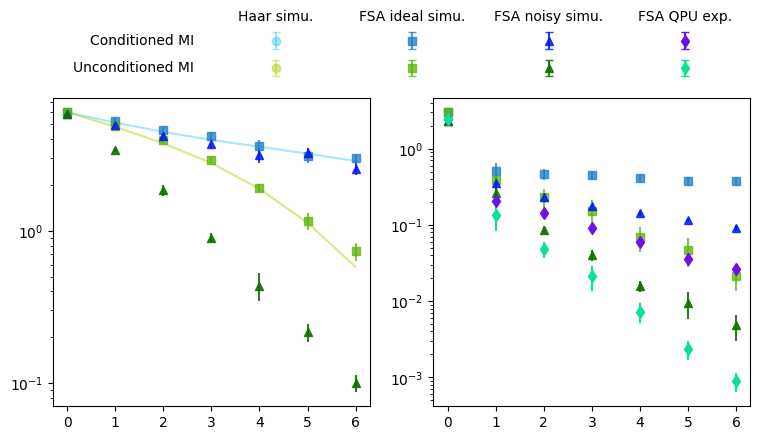

In [ ]:
from matplotlib.lines import Line2D

cell_colors = [["#18bef060", "#1f7eccc5", "#0019fcd6", "#6e10e9"],
               ["#b8d41885", "#59b305bc", "#147201e8", "#0ce290"]]


x = np.arange(T+1)

print(haar_cond_QMI.shape, haar_uncond_QMI.shape)

fig, ax = plt.subplots(1,2, figsize=(9, 4))
# Plot QMI data
ax[0].plot(x, haar_cond_QMI.mean(axis=0), color=cell_colors[0][0])
ax[0].plot(x, haar_uncond_QMI.mean(axis=0), color=cell_colors[1][0])

ax[0].errorbar(x, ideal_random_cond_QMI.mean(axis=0), 
               yerr=ideal_random_cond_QMI.std(axis=0), fmt='s', color=cell_colors[0][1])
ax[0].errorbar(x, ideal_random_uncond_QMI.mean(axis=0), 
               yerr=ideal_random_uncond_QMI.std(axis=0), fmt='s', color=cell_colors[1][1])

ax[0].errorbar(x, noisy_random_cond_QMI.mean(axis=0), 
               yerr=noisy_random_cond_QMI.std(axis=0), fmt='^', color=cell_colors[0][2])
ax[0].errorbar(x, noisy_random_uncond_QMI.mean(axis=0), 
               yerr=noisy_random_uncond_QMI.std(axis=0), fmt='^', color=cell_colors[1][2])
ax[0].set_yscale('log')
# ax[1].plot(x, y2, color='green')

# Plot CMI data
ax[1].errorbar(x, ideal_random_cond_CMI.mean(axis=0), 
               yerr=ideal_random_cond_CMI.std(axis=0), fmt='s', color=cell_colors[0][1])
ax[1].errorbar(x, ideal_random_uncond_CMI.mean(axis=0), 
               yerr=ideal_random_uncond_CMI.std(axis=0), fmt='s', color=cell_colors[1][1])

ax[1].errorbar(x, noisy_random_cond_CMI.mean(axis=0), 
               yerr=noisy_random_cond_CMI.std(axis=0), fmt='^', color=cell_colors[0][2])
ax[1].errorbar(x, noisy_random_uncond_CMI.mean(axis=0), 
               yerr=noisy_random_uncond_CMI.std(axis=0), fmt='^', color=cell_colors[1][2])

ax[1].errorbar(x, torino_dd_cond_CMI.mean(axis=0), 
               yerr=torino_dd_cond_CMI.std(axis=0), fmt='d', color=cell_colors[0][3])
ax[1].errorbar(x, torino_dd_uncond_CMI.mean(axis=0), 
               yerr=torino_dd_uncond_CMI.std(axis=0), fmt='d', color=cell_colors[1][3])

ax[1].set_yscale('log')

# ----- Table-style legend settings -----
col_labels = ["Haar simu.", "FSA ideal simu.", "FSA noisy simu.", "FSA QPU exp."]
row_labels = ["Conditioned MI", "Unconditioned MI"]
marker_styles = ['o', 's', '^', 'd']

# Create an inset axes above the plot to host the table
table_ax = fig.add_axes([0.35, 0.93, 0.5, 0.12])  # [left, bottom, width, height]
table_ax.axis('off')  # hide frame

# draw column titles
for j, col in enumerate(col_labels):
    table_ax.text((j+1)/4, 1.0, col, ha='center', va='bottom', fontsize=10)

# draw row titles and legend handles in cells
for i, row in enumerate(row_labels):
    table_ax.text(0.1, 0.75 - i*0.4, row, ha='right', va='center', fontsize=10)
    # for j, col in enumerate(col_labels):
    #     table_ax.text((j+1)/4, 1.0, col, ha='center', va='bottom', fontsize=10)

    for j in range(len(col_labels)):
        # table_ax.add_line(Line2D([ (j+0.8)/4, (j+1.2)/4],
        #                          [0.75 - i*0.4]*2,
        #                          color=cell_colors[i][j]))
        # table_ax.plot((j+1)/4, 0.75 - i*0.4,
        #               marker='o',
        #               color=cell_colors[i][j])
        table_ax.errorbar((j+1)/4, 0.75 - i*0.4, yerr=0.12, capsize=3, fmt=marker_styles[j], color=cell_colors[i][j])

plt.show()


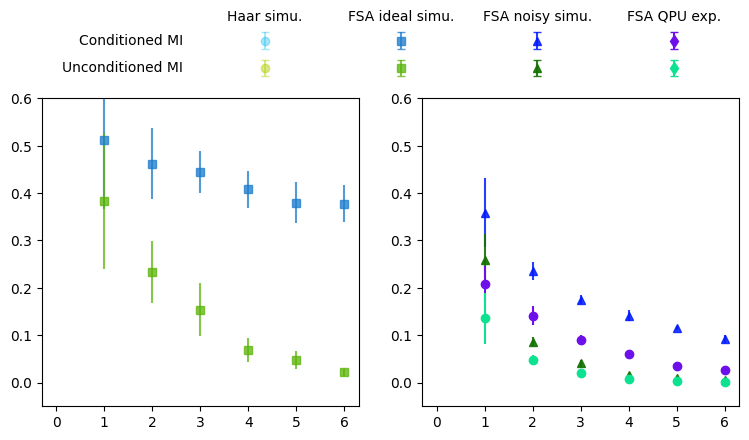

In [12]:
cell_colors = [["#18bef060", "#1f7eccc5", "#0019fcd6", "#6e10e9"],
               ["#b8d41885", "#59b305bc", "#147201e8", "#0ce290"]]


x = np.arange(T+1)

fig, ax = plt.subplots(1,2, figsize=(9, 4))
# Plot QMI data
# ax[0].plot(x, haar_cond_QMI.mean(axis=0), color=cell_colors[0][0])
# ax[0].plot(x, haar_uncond_QMI.mean(axis=0), color=cell_colors[1][0])

# ax[0].errorbar(x, ideal_random_cond_QMI.mean(axis=0), yerr=ideal_random_cond_QMI.std(axis=0), fmt='s', color=cell_colors[0][1])
# ax[0].errorbar(x, ideal_random_uncond_QMI.mean(axis=0), yerr=ideal_random_uncond_QMI.std(axis=0), fmt='s', color=cell_colors[1][1])

# ax[0].errorbar(x, noisy_random_cond_QMI.mean(axis=0), yerr=noisy_random_cond_QMI.std(axis=0), fmt='^', color=cell_colors[0][2])
# ax[0].errorbar(x, noisy_random_uncond_QMI.mean(axis=0), yerr=noisy_random_uncond_QMI.std(axis=0), fmt='^', color=cell_colors[1][2])
# ax[0].set_yscale('log')
# ax[1].plot(x, y2, color='green')

# Plot CMI data
ax[0].errorbar(x, ideal_random_cond_CMI.mean(axis=0), yerr=ideal_random_cond_CMI.std(axis=0), fmt='s', color=cell_colors[0][1])
ax[0].errorbar(x, ideal_random_uncond_CMI.mean(axis=0), yerr=ideal_random_uncond_CMI.std(axis=0), fmt='s', color=cell_colors[1][1])
# ax[0].set_yscale('log')
# ax[0].set_ylim(1e-3, 4)
ax[0].set_ylim(-0.05, 0.6)

ax[1].errorbar(x, noisy_random_cond_CMI.mean(axis=0), yerr=noisy_random_cond_CMI.std(axis=0), fmt='^', color=cell_colors[0][2])
ax[1].errorbar(x, noisy_random_uncond_CMI.mean(axis=0), yerr=noisy_random_uncond_CMI.std(axis=0), fmt='^', color=cell_colors[1][2])

ax[1].errorbar(x, torino_dd_cond_CMI.mean(axis=0), yerr=torino_dd_cond_CMI.std(axis=0), fmt='o', color=cell_colors[0][3])
ax[1].errorbar(x, torino_dd_uncond_CMI.mean(axis=0), yerr=torino_dd_uncond_CMI.std(axis=0), fmt='o', color=cell_colors[1][3])
# ax[1].set_yscale('log')
# ax[1].set_ylim(1e-3, 4)
ax[1].set_ylim(-0.05, 0.6)

# ----- Table-style legend settings -----
col_labels = ["Haar simu.", "FSA ideal simu.", "FSA noisy simu.", "FSA QPU exp."]
row_labels = ["Conditioned MI", "Unconditioned MI"]
marker_styles = ['o', 's', '^', 'd']

# Create an inset axes above the plot to host the table
table_ax = fig.add_axes([0.35, 0.93, 0.5, 0.12])  # [left, bottom, width, height]
table_ax.axis('off')  # hide frame

# draw column titles
for j, col in enumerate(col_labels):
    table_ax.text((j+1)/4, 1.0, col, ha='center', va='bottom', fontsize=10)

# draw row titles and legend handles in cells
for i, row in enumerate(row_labels):
    table_ax.text(0.1, 0.75 - i*0.4, row, ha='right', va='center', fontsize=10)
    # for j, col in enumerate(col_labels):
    #     table_ax.text((j+1)/4, 1.0, col, ha='center', va='bottom', fontsize=10)

    for j in range(len(col_labels)):
        # table_ax.add_line(Line2D([ (j+0.8)/4, (j+1.2)/4],
        #                          [0.75 - i*0.4]*2,
        #                          color=cell_colors[i][j]))
        # table_ax.plot((j+1)/4, 0.75 - i*0.4,
        #               marker='o',
        #               color=cell_colors[i][j])
        table_ax.errorbar((j+1)/4, 0.75 - i*0.4, yerr=0.12, capsize=3, fmt=marker_styles[j], color=cell_colors[i][j])

plt.show()